|<img style="float:left;" src="images/usherb_transp.gif" > |<big><big><big><big>Pierre Proulx, ing, professeur|
|:---|:---|
|<big><big>Département de génie chimique et de génie biotechnologique |<big><big><big><big> GCH200-Phénomènes d'échanges I </big></big>|



#  Chapitre 6: Facteurs de friction:
____
____
____
____
# 1 Définition 


>> ### Le facteur de friction est facteur de proportionnalité défini comme le rapport entre la force de friction exercée sur un objet par un fluide qui s'écoule sur cet objet d'une part, et le produit de l'énergie cinétique du fluide multipliée par la surface. On peut aussi écrire ce coefficient comme le rapport entre la pression exercée sur l'objet par la force de trainée et la pression dynamique du fluide. 

 $$ \boxed { { f  } = \frac {\frac {F_k}{A}}{ \frac {1}{2} \rho V^2}}$$

a) Le facteur de friction défini pour l'écoulement dans une conduite devient ainsi: 
$$
  \boxed{ f = \frac {F_k}{2 \pi R L \big( \frac {1}{2} \rho V^2\big)} }
  $$

$ V $ est la vitesse moyenne de l'écoulement dans la conduite. 

Par un bilan des forces qui s'exercent sur la conduite, on peut relier la force de friction à la différence de pression $\mathscr{P}_0 - \mathscr{P}_L$, et on obtient:

$$
\boxed {F_k = (\mathscr{P}_0 - \mathscr{P}_L)\pi R^2}
$$

En substituant $F_k$ dans la définition de $f$, on obtient la définition générale du coefficient de friction pour une conduite circulaire:

$$
  \boxed{ f =  \frac {1}{4} \frac {D}{L}\frac {\mathscr{P}_0 - \mathscr{P}_L} {(\frac {1}{2} \rho V^2)}} 
  $$

### b) Le facteur de friction défini pour l'écoulement autour d'une sphère en chute libre : 
Le facteur de friction est toujours défini de la même façon

$$ \boxed {f = \frac {\frac {F_k}{A}}{ \frac {1}{2} \rho v_\infty ^2}}$$

mais ici, **attention**, la surface A est la surface projetée de la sphère, donc la surface d'un disque, et $v_\infty $ est la vitesse relative entre le fluide et la sphère.

$$
  \boxed{ f = \frac {F_k}{\pi R^2 \frac {1}{2} \rho v_\infty^2}}
  $$

Par un bilan des forces qui s'exercent sur la sphère (gravité - poussée d'Archimède), on obtient:

$$
\boxed {F_k = \frac {4}{3}\pi R^3 \rho_{sph} g - \frac {4}{3}\pi R^3 \rho g  }
$$

En substituant $F_k$ dans la définition de $f$, on obtient la définition générale du coefficient de friction pour une sphère en chute libre:

$$
  \boxed{ f =  \frac {4}{3} \frac {gD}{v_\infty ^2} \frac {\rho_{sph} -\rho} {\rho}} 
  $$

____
____
____
____
# 2. Facteur de friction pour une conduite

Le résultat obtenu à la section 1a)  est la définition du facteur de friction, ce facteur peut maintenant être déterminé si on connait le profil de vitesse. Il y a deux cas:
* Cas laminaire
$$
\boxed {f = \frac {16}{Re}}
$$


* Cas turbulent

Malheureusement dans le cas turbulent le facteur de friction ne peut pas être déterminé en général de façon aussi simple que dans le cas laminaire et on doit utiliser souvent des corrélations empiriques telles que celles présentées à la section 6.2. Cependant, la relation de Blasius, bien qu'elle soit limitée à des écoulements à des nombres de Reynolds inférieurs à 100,000 et seulement pour des conduites lisses, est souvent utilisée:
$$
\boxed {f = \frac {0.0791}{Re^{0.25}}}
$$
Pour des conduites rugueuses, la formule de Haaland est souvent proposée pour des écoulements fortement turbulents (Re>40,000)
$$
\boxed {\frac {1}{\sqrt{f}} = -3.6 log_{10} \bigg [ \frac {6} {Re} +\big (\frac {k/D}{3.7} \big)^{10/9} \bigg ] }
$$

In [1]:
#
# Utilisons Sympy pour tracer et voir l'influence 
# de Re et k/D, ainsi que la cohérence entre les 2 corrélations
# turbulente ainsi que la partie laminaire
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
import matplotlib.pyplot as plt
import fluids as fl
import thermo as th
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [10]:
Re,ksurD,f=sp.symbols('Re,ksurD,f')
f=sp.Eq(1/(-3.6*sp.log(6/Re+(ksurD/3.7)**(10/9),10))**2,0).lhs
#display(f)
dico={'ksurD':0.0001}
f1=f.subs(dico)
dico={'ksurD':0.0005}                     # Turbulent avec rugosité
f2=f.subs(dico)
dico={'ksurD':0.001}
f3=f.subs(dico)
fBlasius=sp.Eq(0.0791/Re**0.25,0).lhs       # Turbulent jusqu'à 50,000 conduite lisse
fLam=sp.Eq(16/Re,0).lhs                     # laminaire, Re < 2000

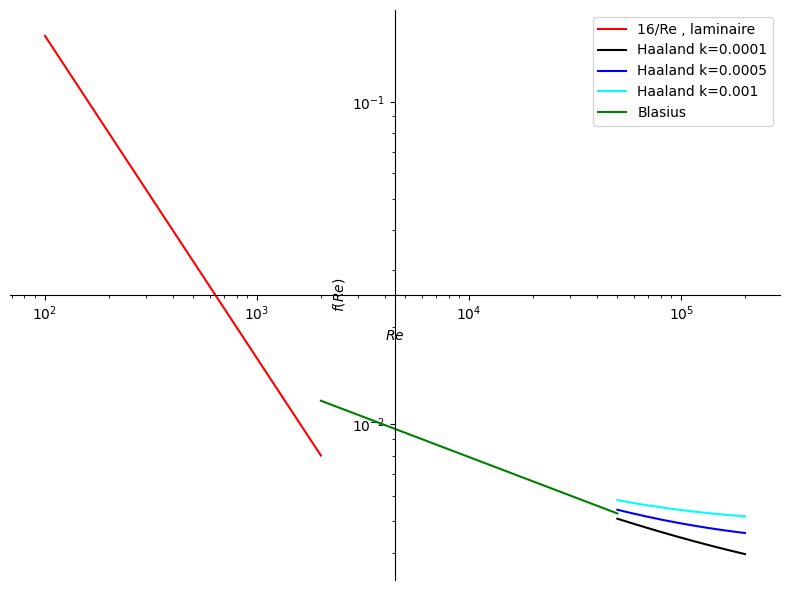

In [11]:
plt.rcParams['figure.figsize'] = 8,6
p=sp.plot((fLam,(Re,100,2000)),
        (f1,(Re,50000,200000)),
        (f2,(Re,50000,200000)),
        (f3,(Re,50000,200000)),
        (fBlasius,(Re,2000,50000)),legend=True,\
          xscale='log',yscale='log',show=False);
p[0].line_color = 'red'
p[0].label='16/Re , laminaire'
p[1].line_color = 'black'
p[1].label='Haaland k=0.0001'
p[2].line_color = 'blue'
p[2].label='Haaland k=0.0005'
p[3].line_color = 'cyan'
p[3].label='Haaland k=0.001'
p[4].line_color = 'green'
p[4].label='Blasius'
p.show()

### Utilisation de *fluids*

In [12]:
def facteurDeFrictionConduite(Re,e):
    fd=fl.friction_factor(Re,e)
    print('      rugosité     f Darcy    f Blasius  0.0791/Re**0.25')
    print('{:0.6f} e/D        f={:7.5f}  f={:6.5f}  f*={:6.5f}'.format(e,fd,fd/4,0.0791/Re**0.25))    
interactive(facteurDeFrictionConduite,\
            Re=widgets.FloatSlider(min=100,max=200000,step=100,value=10),\
            e=widgets.FloatLogSlider(value=-3,base=10,min=-4,max=-2,step=0.1))

interactive(children=(FloatSlider(value=100.0, description='Re', max=200000.0, min=100.0, step=100.0), FloatLo…